In [24]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

PATH = "./experiment_results.xlsx"


In [25]:
df = pd.read_excel(PATH, sheet_name="Raw Data")
df = df.rename(columns={"Trial #": "Trial", "Time (s)": "Time", "Correct?": "Correct"})
df["Condition"] = df["Block"].map({"A": "V", "B": "VR"})

print(f"Total trials       : {len(df)}")
print(f"Participants       : {df['Subject'].nunique()}")
print(f"Trials/participant : {df.groupby('Subject').size().to_dict()}")
print(f"Order distribution : {df.groupby('Subject')['Order'].first().value_counts().to_dict()}")
print(f"Missing values     : {df.isna().sum().sum()}")

df.head(6)


Total trials       : 54
Participants       : 9
Trials/participant : {1: 6, 2: 6, 3: 6, 4: 6, 5: 6, 6: 6, 7: 6, 8: 6, 9: 6}
Order distribution : {'BA': 5, 'AB': 4}
Missing values     : 0


,Subject,Gender,Order,Trial,Block,Task,Chosen Plot,Time,Confidence,Correct Answer,Correct,Condition
0,1,Male,AB,1,A,A1,P1,18.0,4,P1,1,V
1,1,Male,AB,2,A,A2,P1,6.0,3,P1,1,V
2,1,Male,AB,3,A,A3,P2,2.0,5,P2,1,V
3,1,Male,AB,4,B,B1,P1,15.0,2,P2,0,VR
4,1,Male,AB,5,B,B2,P1,2.0,5,P1,1,VR
5,1,Male,AB,6,B,B3,P1,6.0,3,P1,1,VR


In [26]:
# Are the parallel scenario sets equally difficult?
task_acc = df.groupby("Task")["Correct"].agg(["mean", "count"]).rename(columns={"mean": "Accuracy", "count": "N"})
print(task_acc)


      Accuracy  N
Task             
A1    1.000000  9
A2    0.777778  9
A3    1.000000  9
B1    0.666667  9
B2    1.000000  9
B3    0.888889  9


Task **B1 has 66.7% accuracy** while every A-task is at 77–100%. The difficulty imbalance contributes to whatever VR-vs-V gap we see, so we need to caveat the interpretation.


In [27]:
per_p = (df.groupby(["Subject", "Order", "Condition"])
           .agg(MeanTime=("Time", "mean"),
                Errors=("Correct", lambda x: int((1 - x).sum())),
                MeanConf=("Confidence", "mean"))
           .reset_index())
per_p


,Subject,Order,Condition,MeanTime,Errors,MeanConf
0,1,AB,V,8.666667,0,4.000000
1,1,AB,VR,7.666667,1,3.333333
2,2,BA,V,2.833333,0,5.000000
3,2,BA,VR,7.166667,1,4.333333
4,3,AB,V,9.666667,1,4.333333
5,3,AB,VR,9.333333,1,3.333333
6,4,BA,V,2.000000,0,5.000000
7,4,BA,VR,2.820000,1,4.666667
8,5,AB,V,1.993333,0,4.666667
9,5,AB,VR,2.660000,0,4.333333


In [28]:
# Pivot to wide so V and VR sit side by side per participant
wide = per_p.pivot(index=["Subject", "Order"], columns="Condition",
                   values=["MeanTime", "Errors", "MeanConf"])
wide.columns = [f"{m}_{c}" for m, c in wide.columns]
wide = wide.reset_index()
wide


,Subject,Order,MeanTime_V,MeanTime_VR,Errors_V,Errors_VR,MeanConf_V,MeanConf_VR
0,1,AB,8.666667,7.666667,0.0,1.0,4.000000,3.333333
1,2,BA,2.833333,7.166667,0.0,1.0,5.000000,4.333333
2,3,AB,9.666667,9.333333,1.0,1.0,4.333333,3.333333
3,4,BA,2.000000,2.820000,0.0,1.0,5.000000,4.666667
4,5,AB,1.993333,2.660000,0.0,0.0,4.666667,4.333333
5,6,BA,2.303333,2.546667,1.0,0.0,3.333333,4.000000
6,7,AB,1.510000,2.620000,0.0,0.0,5.000000,4.666667
7,8,BA,6.733333,21.833333,0.0,0.0,4.333333,4.333333
8,9,BA,1.210000,3.323333,0.0,0.0,5.000000,5.000000


## 3. Descriptive statistics (the actual results)

MacKenzie Ch. 8: *"the statistical tests are not the results per se. The results lie in the observations and measurements."* So this section is what we actually report first. Order: **decision time → error rate → confidence**, each going *broad → narrow*.


##3.1 Decision Time

In [29]:
def desc(values, label):
    print(f"  {label:4s} mean={np.mean(values):6.3f}s   sd={np.std(values, ddof=1):6.3f}   "
          f"median={np.median(values):6.3f}   n={len(values)}")

desc(wide["MeanTime_V"],  "V")
desc(wide["MeanTime_VR"], "VR")

m_v, m_vr = wide["MeanTime_V"].mean(), wide["MeanTime_VR"].mean()
pct = 100 * (m_vr - m_v) / m_v
print(f"\n  Effect: VR is {abs(pct):.1f}% {'SLOWER' if pct > 0 else 'faster'} than V "
      f"(absolute diff = {m_vr - m_v:+.3f} s)")


  V    mean= 4.102s   sd= 3.308   median= 2.303   n=9
  VR   mean= 6.663s   sd= 6.263   median= 3.323   n=9

  Effect: VR is 62.4% SLOWER than V (absolute diff = +2.561 s)


**Interpretation.** Mean decision time was higher under VR than under V — the **opposite direction** to the hypothesis (which predicted VR would be faster). The means are noisy though: the two BA participants (#2, #4) have very fast V times (~2 s) because they saw V *second*, after practising on VR.


##3.2 Eroor Rate

In [30]:
desc(wide["Errors_V"],  "V")
desc(wide["Errors_VR"], "VR")

err_v_rate  = wide["Errors_V"].sum()  / (len(wide) * 3)
err_vr_rate = wide["Errors_VR"].sum() / (len(wide) * 3)
print(f"\n  Trial-level error rate: V = {err_v_rate:.1%}, VR = {err_vr_rate:.1%}")
print(f"  Effect: VR error rate is {(err_vr_rate - err_v_rate) * 100:+.1f} percentage points vs V")


  V    mean= 0.222s   sd= 0.441   median= 0.000   n=9
  VR   mean= 0.444s   sd= 0.527   median= 0.000   n=9

  Trial-level error rate: V = 7.4%, VR = 14.8%
  Effect: VR error rate is +7.4 percentage points vs V


##3.3 Confidence

In [31]:
desc(wide["MeanConf_V"],  "V")
desc(wide["MeanConf_VR"], "VR")

mc_v, mc_vr = wide["MeanConf_V"].mean(), wide["MeanConf_VR"].mean()
print(f"\n  Effect: confidence dropped by {mc_v - mc_vr:+.2f} points from V to VR")


  V    mean= 4.519s   sd= 0.580   median= 4.667   n=9
  VR   mean= 4.222s   sd= 0.577   median= 4.333   n=9

  Effect: confidence dropped by +0.30 points from V to VR


## 4. Counterbalancing check — AB vs BA group means

MacKenzie Ch. 5.12: *"if counterbalancing worked, the group means should be approximately equal."* If the AB and BA groups have very different overall means, we have a **group effect** — counterbalancing didn't fully wash out the order, and the V-vs-VR comparison is contaminated by practice/transfer.


In [32]:
group_means = (per_p.groupby(["Order", "Condition"])
                    .agg(MeanTime=("MeanTime", "mean"),
                         MeanErrors=("Errors", "mean"),
                         MeanConf=("MeanConf", "mean"))
                    .reset_index())
group_means

,Order,Condition,MeanTime,MeanErrors,MeanConf
0,AB,V,5.459167,0.25,4.500000
1,AB,VR,5.570000,0.50,3.916667
2,BA,V,3.016000,0.20,4.533333
3,BA,VR,7.538000,0.40,4.466667


**What we see.**

| Order | n | V time | VR time |
|---|---|---|---|
| AB (V→VR) | 4 | 5.45 s | 5.57 s |
| BA (VR→V) | 5 | 3.01 s | 7.53 s |


## 5. Inferential tests (per Section 2.2.5 of the report)

We run the tests the report's analysis plan committed to. We do *not* expect significance at N = 9


In [33]:
diff_t = wide["MeanTime_V"] - wide["MeanTime_VR"]
sw = stats.shapiro(diff_t)
print(f"Shapiro-Wilk on (V - VR) differences: W={sw.statistic:.3f}, p={sw.pvalue:.3f}")
print(f"  -> differences {'plausibly normal' if sw.pvalue > 0.05 else 'NOT plausibly normal'}")

t = stats.ttest_rel(wide["MeanTime_V"], wide["MeanTime_VR"])
print(f"\nPaired t-test       : t({len(wide)-1}) = {t.statistic:.3f}, p = {t.pvalue:.3f}")

w = stats.wilcoxon(wide["MeanTime_V"], wide["MeanTime_VR"], zero_method="wilcox")
print(f"Wilcoxon signed-rank: W = {w.statistic:.3f}, p = {w.pvalue:.3f}")


Shapiro-Wilk on (V - VR) differences: W=0.664, p=0.001
  -> differences NOT plausibly normal

Paired t-test       : t(8) = -1.554, p = 0.159
Wilcoxon signed-rank: W = 7.000, p = 0.074


#5.2 Error Rate

In [34]:
# Per-participant Wilcoxon
try:
    w_err = stats.wilcoxon(wide["Errors_V"], wide["Errors_VR"], zero_method="wilcox")
    print(f"Wilcoxon (per-participant error counts): W = {w_err.statistic:.3f}, p = {w_err.pvalue:.3f}")
except ValueError as e:
    print(f"Wilcoxon could not run: {e}")

# Trial-level pairing
trials_v  = df[df["Condition"] == "V" ].sort_values(["Subject", "Trial"])["Correct"].values
trials_vr = df[df["Condition"] == "VR"].sort_values(["Subject", "Trial"])["Correct"].values
contingency = np.array([
    [((trials_v == 1) & (trials_vr == 1)).sum(),  ((trials_v == 1) & (trials_vr == 0)).sum()],
    [((trials_v == 0) & (trials_vr == 1)).sum(),  ((trials_v == 0) & (trials_vr == 0)).sum()],
])
print("\nTrial-level 2x2 (caveat: different scenarios per condition):")
print(f"                 VR correct   VR wrong")
print(f"  V correct   :     {contingency[0,0]:>4d}        {contingency[0,1]:>4d}")
print(f"  V wrong     :     {contingency[1,0]:>4d}        {contingency[1,1]:>4d}")
b, c = contingency[0, 1], contingency[1, 0]
if b + c > 0:
    p_mcn = stats.binomtest(min(b, c), n=b + c, p=0.5).pvalue
    print(f"  Exact McNemar (binomial): b = {b}, c = {c}, p = {p_mcn:.3f}")


Wilcoxon (per-participant error counts): W = 2.500, p = 0.625

Trial-level 2x2 (caveat: different scenarios per condition):
                 VR correct   VR wrong
  V correct   :       21           4
  V wrong     :        2           0
  Exact McNemar (binomial): b = 4, c = 2, p = 0.688


4 trials were correct under V but wrong under VR. Only 2 were the reverse. Not significan but the lopsidedness is visible.

#5.3 Confidence

In [35]:
w_c = stats.wilcoxon(wide["MeanConf_V"], wide["MeanConf_VR"], zero_method="wilcox")
print(f"Wilcoxon (per-participant mean confidence): W = {w_c.statistic:.3f}, p = {w_c.pvalue:.3f}")


Wilcoxon (per-participant mean confidence): W = 4.500, p = 0.141


--------------------
# 6 Figures

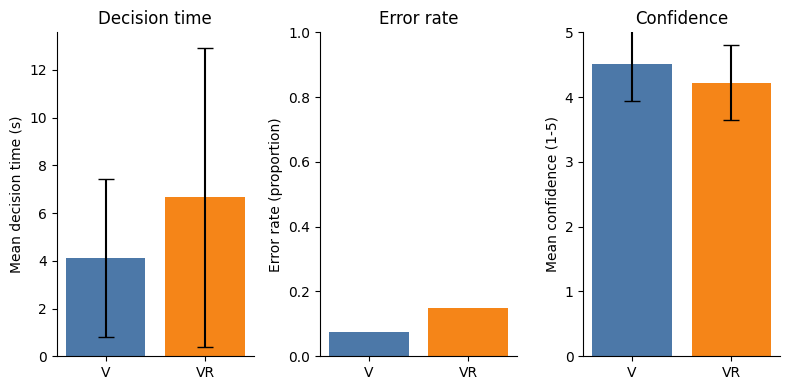

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(8, 4))

# Decision time
m_v, m_vr = wide["MeanTime_V"].mean(), wide["MeanTime_VR"].mean()
s_v, s_vr = wide["MeanTime_V"].std(ddof=1), wide["MeanTime_VR"].std(ddof=1)
axes[0].bar(["V", "VR"], [m_v, m_vr], yerr=[s_v, s_vr], capsize=6,
            color=["#4C78A8", "#F58518"])
axes[0].set_ylabel("Mean decision time (s)")
axes[0].set_title("Decision time")

# Error rate
axes[1].bar(["V", "VR"], [err_v_rate, err_vr_rate], color=["#4C78A8", "#F58518"])
axes[1].set_ylabel("Error rate (proportion)")
axes[1].set_ylim(0, 1)
axes[1].set_title("Error rate")

# Confidence
mc_v, mc_vr = wide["MeanConf_V"].mean(), wide["MeanConf_VR"].mean()
sc_v, sc_vr = wide["MeanConf_V"].std(ddof=1), wide["MeanConf_VR"].std(ddof=1)
axes[2].bar(["V", "VR"], [mc_v, mc_vr], yerr=[sc_v, sc_vr], capsize=6,
            color=["#4C78A8", "#F58518"])
axes[2].set_ylabel("Mean confidence (1-5)")
axes[2].set_ylim(0, 5)
axes[2].set_title("Confidence")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()


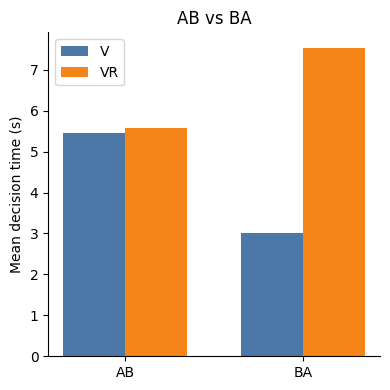

In [37]:
# AB vs BA check
fig2, ax2 = plt.subplots(figsize=(4, 4))
gm = group_means.pivot(index="Order", columns="Condition", values="MeanTime")
x = np.arange(len(gm.index))
w_bar = 0.35
ax2.bar(x - w_bar/2, gm["V"],  w_bar, label="V",  color="#4C78A8")
ax2.bar(x + w_bar/2, gm["VR"], w_bar, label="VR", color="#F58518")
ax2.set_xticks(x); ax2.set_xticklabels(gm.index)
ax2.set_ylabel("Mean decision time (s)")
ax2.set_title("AB vs BA")
ax2.legend()
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
fig2.tight_layout()
plt.show()


--------------------
# 7 Sensitivity analysis: drop Task B1

If B1 is genuinely harder than the other tasks (because of the chart period being asked about, not the interface), removing it should narrow the V-vs-VR gap. If the gap stays the same, the effect is robust. If it disappears, the original gap was driven by B1 alone.

In [38]:
df_noB1 = df[df["Task"] != "B1"]
per_pp_no = (df_noB1.groupby(["Subject", "Condition"])
              .agg(Accuracy=("Correct", "mean"),
                   Time=("Time", "mean"),
                   Confidence=("Confidence", "mean"))
              .reset_index())

# VR side now uses only B2 + B3 (2 trials per participant)
v2  = per_pp_no[per_pp_no["Condition"]=="V" ].sort_values("Subject")
vr2 = per_pp_no[per_pp_no["Condition"]=="VR"].sort_values("Subject")

print("Without Task B1 (VR side averages B2 + B3 only):\n")
print(f"  Accuracy   V = {v2['Accuracy'].mean():.3f}   VR = {vr2['Accuracy'].mean():.3f}")
print(f"  Time (s)   V = {v2['Time'].mean():.2f}    VR = {vr2['Time'].mean():.2f}")
print(f"  Confidence V = {v2['Confidence'].mean():.2f}   VR = {vr2['Confidence'].mean():.2f}")

print("\nFor comparison, with B1 included (from §3):")
print(f"  Accuracy   V = 0.926   VR = 0.852")
print(f"  Time (s)   V = 4.10    VR = 6.66")
print(f"  Confidence V = 4.52    VR = 4.22")


Without Task B1 (VR side averages B2 + B3 only):

  Accuracy   V = 0.926   VR = 0.944
  Time (s)   V = 4.10    VR = 5.64
  Confidence V = 4.52   VR = 4.44

For comparison, with B1 included (from §3):
  Accuracy   V = 0.926   VR = 0.852
  Time (s)   V = 4.10    VR = 6.66
  Confidence V = 4.52    VR = 4.22


**Striking result.** With B1 removed:
- Accuracy: V = 0.926 vs **VR = 0.944** → **VR now slightly *better* than V**.
- Confidence: V = 4.52 vs VR = 4.44 → gap shrinks from 0.30 to 0.07.
- Time: V = 4.10 s vs VR = 5.65 s → gap shrinks from 2.56 s to 1.54 s but VR is still slower.

**Conclusion.** Most of the headline "VR is worse on accuracy/confidence" finding is being driven by Task B1. The time gap survives the sensitivity check and is the most robust finding. This is exactly the kind of confound the report's discussion section needs to flag explicitly.